In [1]:
%load_ext autoreload
%autoreload 2
import importlib 
m = importlib.import_module(".model", "src")
em = importlib.import_module(".em", "src")
sem = importlib.import_module(".sem", "src") # my implementation of baby SEM
moments = importlib.import_module(".moments", "src")
from matplotlib import pyplot as plt
import numpy as np
from scipy.optimize import fsolve
from itertools import product
import pandas as pd 
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import xgi
import scipy.special as ss
import pickle

def expectation(x):
    
    to_sum = [(i)*j for i,j in enumerate(x)]
      
    return sum(to_sum)

C:\Users\hexie\.conda\envs\Hgraph\lib\site-packages\xgi\__init__.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
C:\Users\hexie\.conda\envs\Hgraph\lib\site-packages\xgi\utils\utilities.py:9: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
dataset = "email-enron"
H = xgi.load_xgi_data(dataset)
GH = m.GrowingHypergraph(H)

In [14]:
GH.H.num_edges
GH.edge_neighborhood(GH.H.num_edges-1)

{37,
 38,
 39,
 41,
 733,
 735,
 942,
 1028,
 2359,
 2394,
 2555,
 2556,
 2557,
 2558,
 2559,
 2560,
 2561,
 2562,
 2563,
 2564,
 2565,
 2566,
 2567,
 2568,
 2569,
 2570,
 2571,
 2572,
 2573,
 2574,
 2575,
 2576,
 2577,
 2578,
 2579,
 2580,
 2581,
 2582,
 2583,
 2584,
 2585,
 2586,
 2587,
 2588,
 2589,
 2590,
 2591,
 2592,
 2593,
 2594,
 2595,
 2596,
 2597,
 2598,
 2599,
 2600,
 2601,
 2602,
 2603,
 2604,
 2605,
 2606,
 2607,
 2608,
 2609,
 2610,
 2611,
 2612,
 2613,
 2614,
 2615,
 2616,
 2617,
 2618,
 2619,
 2620,
 2621,
 2622,
 2623,
 2624,
 2625,
 2626,
 2627,
 2628,
 2629,
 2630,
 2631,
 2632,
 2633,
 2634,
 2635,
 2636,
 2637,
 2638,
 2639,
 2640,
 2641,
 2642,
 2643,
 2644,
 2645,
 3487,
 3592,
 3595,
 3596,
 3597,
 3647,
 3648,
 3677,
 4523,
 4537,
 4569,
 4593,
 4859,
 4906,
 5702,
 5708,
 5718,
 5805,
 5812,
 5822,
 5841,
 5875,
 5930,
 5946,
 5954,
 6009,
 6133,
 6134,
 6135,
 6137,
 6176,
 6181,
 6182,
 6183,
 6185,
 6187,
 6192,
 6199,
 6235,
 6239,
 6254,
 6255,
 6256,
 62

In [3]:
# estimated from EM
with open('sem_results_new/res_{}.pkl'.format(dataset + "_SEM_new"), "rb") as f:
    d = pickle.load(f)

eta = np.mean(d["eta"][-50:])
beta = np.mean(d["beta"][-50:], axis=0)
gamma = np.mean(d["gamma"][-50:], axis=0)
#eta   = 0.88
#beta  = 0.013
#gamma = 0.12

In [4]:
mean_edge_size = 1 + (expectation(beta) + expectation(gamma)) / (1-eta)
param_for_alternatives = mean_edge_size - expectation(beta) - 1

Enron Email
Proposed Model
Growing Erdős-Rényi


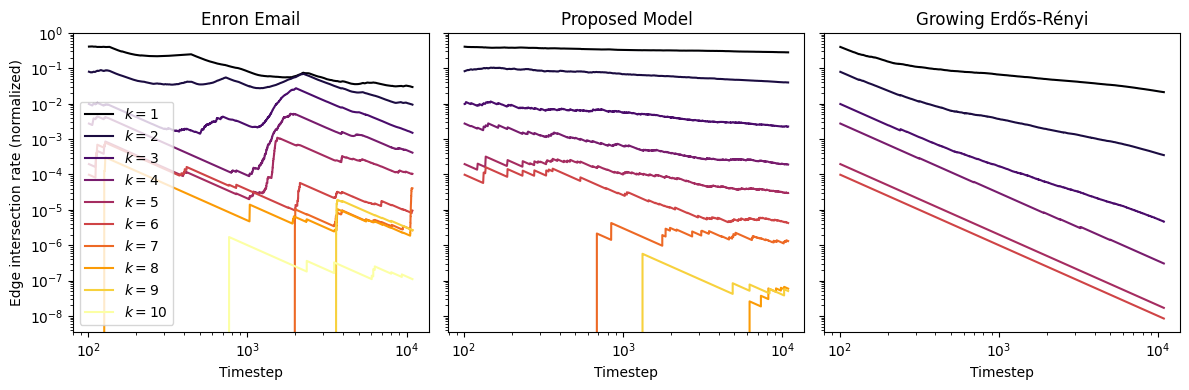

In [7]:
models = ["Enron Email", "Proposed Model", "Growing Erdős-Rényi"]
fig, ax = plt.subplots(1, 3, figsize = (12, 4), sharey=True)
max_k = 10

inferno = mpl.colormaps['inferno'].resampled(max_k)

num_init = 100
num_steps = len(GH.edge_size_sequence()) - num_init 
interval = 1
 
for i in range(3):
    model = models[i]
    print(model)
    ax[i].loglog()
    ax[i].set(title = f"{model}")
    ax[i].set(xlabel = "Timestep")
    
    if i == 0:
        H = GH 
    else: 
        H = m.GrowingHypergraph()
        for j in range(num_init):
            H.add_edge(GH.edges.members(j))
        for _ in range(num_steps):
            if i == 1: 
                H.sample_edge(eta, gamma, beta, True)
            elif i == 2: 
                H.sample_edge_alternative("ER", param_for_alternatives, expectation(beta))
    
    D, timesteps = H.intersection_profile(randomize = False, interval = interval)

    for k in sorted(list(D.keys())): 
        if k <= max_k:
            ax[i].plot(timesteps[num_init:], D[k][num_init:], label = rf"$k = {k}$", color = inferno(k-1))
    
ax[0].legend()
ax[0].set(ylabel = "Edge intersection rate (normalized)")
plt.tight_layout()
plt.savefig("figures/intersection-profiles-comparison.pdf",bbox_inches='tight')

In [19]:
plt.savefig("figures/intersection-profiles-comparison.pdf", bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [95]:

num_init = 2
num_steps = 20000 - num_init 
interval = 1
max_k = 4

num_in_graph = 1
num_new = 1

H = m.GrowingHypergraph()
for j in range(num_init):
    H.add_edge(GH.edges.members(j))

for i in range(num_steps):
    H.sample_edge_alternative("ER", num_in_graph, num_new)

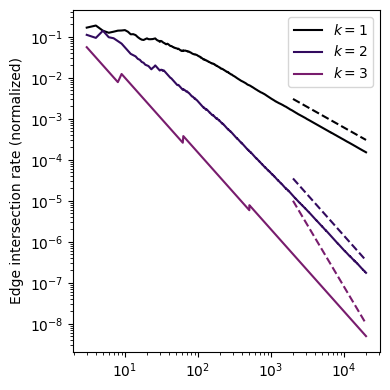

In [109]:
D, timesteps = H.intersection_profile(randomize = False)
fig, ax = plt.subplots(1, 1, figsize = (4, 4), sharey=True)

ax.loglog()

max_k = 6
inferno = mpl.colormaps['inferno'].resampled(max_k+1)

for k in sorted(list(D.keys())): 
    if k <= max_k:
        ax.plot(timesteps[num_init:], D[k][num_init:], label = rf"$k = {k}$", color = inferno(k-1))
        C = D[k][-1]*(timesteps[-1]**k)
        x = np.linspace(timesteps[-1]/10, timesteps[-1], 10)
        y = 2*D[k][-1]*(x/(timesteps[-1]))**(-k)
        ax.plot(x, y, color = inferno(k-1), linestyle = "--")
        
ax.legend()
ax.set(ylabel = "Edge intersection rate (normalized)")
plt.tight_layout()

/tmp/ipykernel_46767/1864381328.py:1: RuntimeWarning: divide by zero encountered in log
  plt.plot(np.log(D[6]))


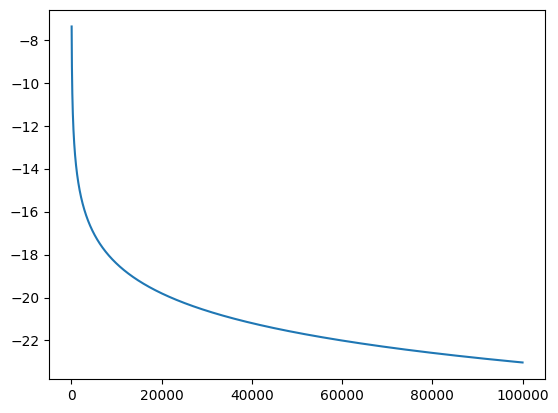

In [86]:
plt.plot(np.log(D[6]))

In [ ]:
fig, ax = plt.subplots(1, 1, figsize = (4, 4), sharey=True)

123 197.45528455284554 2.4279716085174448
155 136.4967741935484 2.1150654803558933
152 138.52631578947367 2.1049685094471657


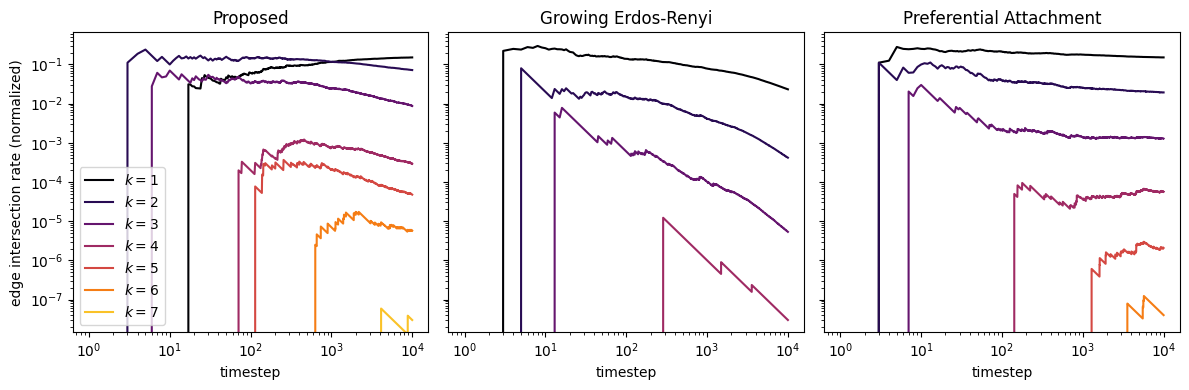

In [13]:
# eta   = 0.8
# beta  = 0.5
# gamma = 0.1

mean_edge_size = 1 + (beta + gamma) / (1-eta)

param_for_alternatives = mean_edge_size - beta - 1

models = {
    "ours" : "Proposed",
    "PA"   : "Preferential Attachment",
    "ER"   : "Growing Erdos-Renyi"
}

fig, ax = plt.subplots(1, 3, figsize = (12, 4), sharey=True)

interval = 1              
max_k = 8

inferno = mpl.colormaps['inferno'].resampled(max_k)

num_steps = int(1e4)

for i in [0, 1, 2]:
    H = m.GrowingHypergraph()
    H.add_edge((0, 1, 10))
    H.add_edge((2, 3, 7))
    H.add_edge((4, 5))
    if i > 0:
        step_type = ["ER", "PA"][i-1]

        for _ in range(num_steps):
            H.sample_edge_alternative(step_type, param_for_alternatives, beta)
    else:
        step_type = "ours"
        for _ in range(num_steps):
            H.sample_edge(eta, gamma, beta, True)
    print(len(H.degree_sequence()), H.degree_sequence().mean(), H.edge_size_sequence().mean())
    
    D, timesteps = H.intersection_profile(randomize = False, interval = interval)

    for k in sorted(list(D.keys())): 
        if k <= max_k:
            ax[i].plot(timesteps, D[k], label = rf"$k = {k}$", color = inferno(k-1))
    ax[i].loglog()
    ax[i].set(title = f"{models[step_type]}")
    ax[i].set(xlabel = "timestep")
ax[0].legend()
ax[0].set(ylabel = "edge intersection rate (normalized)")
plt.tight_layout()

In [33]:
(H.degree_sequence()**2).mean()

345290.8591549296

In [31]:
H = m.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))
H.add_edge((4, 5))

for _ in range(num_steps):
    H.sample_edge(eta, gamma, beta, True)

In [32]:
H.degree_sequence()

array([2628, 2462, 3539, 3196, 2711, 2354,  493,  186,  220,  138,  104,
        112,   68,   80,   65,   81,   74,   52,   74,   46,   47,   32,
         51,   48,   21,   27,   39,   40,   34,   13,   31,   36,   35,
         14,   28,   19,   13,   17,   28,   21,   24,   16,   19,   22,
         14,    9,    8,   20,    7,   30,    8,   11,   10,   10,    8,
         13,   21,    7,    9,    7,    9,   14,   15,    8,   11,    8,
         13,   10,    5,    5,    8,    5,    5,    7,    5,    9,   16,
          7,    8,   10,    5,    6,    3,    5,    3,    9,    5,    7,
          7,    6,    3,    2,    3,    4,    2,    9,    4,    7,    4,
          4,    6,    4,    3,    3,    2,    3,    6,    4,    2,    2,
          4,    4,    1,    4,    5,    3,    2,    5,    4,    1,    8,
          4,    4,    1,    2,    4,    1,    1,    4,    1,    2,    2,
          1,    2,    1,    1,    2,    1,    1,    1,    1,    1])

In [130]:
step_type = "PA"
H = m.GrowingHypergraph()
H.add_edge((0, 1, 10, 11))
H.add_edge((2, 3, 7, 8))
H.add_edge((4, 5, 6, 9))
for _ in range(num_steps):
    H.sample_edge_alternative(step_type, param_for_alternatives, beta)

In [131]:
H.H.edges.members()

[{0, 1, 10, 11},
 {2, 3, 7, 8},
 {4, 5, 6, 9},
 {5, 7, 9},
 {2},
 {5, 7},
 {4, 7, 11},
 {7},
 {5, 7, 8},
 {2, 8},
 {2, 3, 10},
 {0},
 {7},
 {4},
 {4},
 {6, 8},
 {3, 5, 6},
 {0, 7},
 {5, 10},
 {5, 9, 10},
 {0, 7, 10},
 {1, 5, 9},
 {0, 7},
 {7, 8},
 {8},
 {3, 7},
 {0, 10},
 {0, 11},
 {0, 2, 3, 9},
 {0, 2, 4, 5},
 {0, 2, 3, 4, 7},
 {4, 7},
 {5, 6, 7, 9},
 {0, 5},
 {5, 10},
 {2, 4},
 {3, 5},
 {0, 3, 6, 7},
 {6, 7, 9},
 {6, 10},
 {2, 5, 8, 11},
 {6, 10, 12},
 {11},
 {0, 7, 9, 10, 11, 12},
 {2, 5, 6, 10},
 {6, 8, 10},
 {2, 7, 10},
 {9},
 {3, 7, 8},
 {0, 4, 9, 11},
 {4},
 {11},
 {2, 4, 5, 6, 10},
 {0, 6},
 {4, 9, 10, 13},
 {2, 5, 6, 7, 10},
 {9, 11},
 {7},
 {5, 8},
 {8, 10},
 {0, 6, 9, 11},
 {0, 9, 10},
 {2, 4, 5, 6},
 {0, 4},
 {0, 7, 8, 10},
 {5, 10},
 {2, 7, 8},
 {6, 7, 9},
 {3, 6, 7, 10},
 {7},
 {4, 10},
 {2, 7, 9},
 {0, 8, 9, 13},
 {4, 11},
 {7, 9},
 {0, 11},
 {5, 7},
 {8, 11},
 {2, 8},
 {2, 9, 11},
 {4, 7},
 {10},
 {0, 2, 10},
 {0, 13},
 {0, 2},
 {0, 3, 4},
 {0, 3, 4},
 {0, 3, 9, 10},
 {

In [132]:
H.degree_sequence()

array([2102,  611, 2305, 1706, 2028, 2347, 1699, 2855, 2058, 1957, 2362,
       1691,  650,  155,   18,   43,   56,    1,    4,   27,   57,    1,
          8,   14,   34,   13,    3,    7,    1,   23,    3,    1,    4,
          1,    6,    6,    1,    1,    1,    4,    5,    6,    3,    2,
          8,    7,    1,    1,    2,    5,    1,    1,    4,    5,    2,
          4,    1,    1,    2,    2,    1,    1,    7,    1,    8,    5,
          2,    1,    4,    1,    1,    1,    1,    1,    1,    2,    1,
          3,    2,    2,    5,    1,    1,    1,    1,    1,    2,    2,
          1,    1,    3,    2,    1,    2,    7,    1,    2,    2,    2,
          3,    1,    1,    1,    1,    1,    1,    2,    2,    1,    1,
          1,    1,    1,    1,    1,    1,    1,    1,    2,    1,    2,
          1,    2,    1,    3,    1,    1,    1,    1,    1,    1,    1,
          1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1])

## Similar Figure, With Parameters from Data

In [137]:
dataset = "email-enron"
H = xgi.load_xgi_data(dataset)
H = m.GrowingHypergraph(H, filter_singletons = True)

In [138]:
H.degree_sequence()

array([ 192,  257,  117,   62,  157,  388,  503,  138,   23,   85,   48,
        125,   72,  134,  751,   66,   49,   27,  376,  175, 1282,  305,
        880,  906,  469,  233,   93,  205,  387,  209,  354,  943,   94,
        490,   83,  108,  237,  172,  144,  226,  479,   70,   43,  202,
         49,  157,  137,   46,  165,   75,   56,   33,   20,   37,   35,
        626, 1281, 1096,  322,  466,  271,  414,   28,  111,  142,  240,
         38,   19,   12,    6,   18,  122,  393,   16,   32,  131,    3,
         74,   48,   11,  146,   50,  164,   22,   49,   57,    5,   12,
         18,   15,   40,  117,    6,    5,  169,  140,   70,  316,   65,
         97,  325,  195,  209,  260,  419,   69,   54,  296,  338,   78,
         58,   47,   83,  280,   51,   19,   30,  111,   14,   22,  428,
         25,  355,  117,   66,   24,  308,  150,   29,   20,   15,  116,
        153,  280,  123,  130,   18,  352,   18,   11,   21,   10,  104])

In [33]:
EM = sem.SEM_vr(H, pars = {"eta"   : 0.3, 
                           "beta"  : 0.4, 
                           "gamma" : 0.02})

for i in range(10000): 
    EM.SEM_step(0.002) 
    if i % 500 == 0:
        print(EM.pars)

{'eta': 0.30069971927027095, 'beta': 0.3996, 'gamma': 0.019985721905753852}
{'eta': 0.5841731862950151, 'beta': 0.1671220877132095, 'gamma': 0.062186999018269136}
{'eta': 0.7336572444675737, 'beta': 0.07206228037039, 'gamma': 0.10190218163214701}
{'eta': 0.8267683016642713, 'beta': 0.0284850992776365, 'gamma': 0.08232750670932008}
{'eta': 0.8447155539532353, 'beta': 0.014621951025796597, 'gamma': 0.09965735132297683}
{'eta': 0.8630555548362151, 'beta': 0.009404137030298654, 'gamma': 0.1038492081045753}
{'eta': 0.8834627768144104, 'beta': 0.005174344792779049, 'gamma': 0.09311111488415008}
{'eta': 0.8877170974630771, 'beta': 0.00895446704472519, 'gamma': 0.14458513509208004}
{'eta': 0.8953898835771021, 'beta': 0.009745407932278112, 'gamma': 0.10013401857249415}
{'eta': 0.8823692099261775, 'beta': 0.005099282618492856, 'gamma': 0.13376030614368722}
{'eta': 0.8848692934403076, 'beta': 0.007417909018057251, 'gamma': 0.13154379021321957}
{'eta': 0.8867492085100491, 'beta': 0.010297809835267

In [53]:
# estimator likelihood definitions
# pmfs are used in E-step
# m_step estimators are the parameter estimators for each distribution
# used in m-step, using the matrix chi formed in the E-step

# edge sampling
def edge_sample_pmf(x, t, eta):
    return (eta**x)*((1-eta)**(t-x))

def edge_sample_m_step(x, t, chi):
    C = np.tril(chi,-1)
    return (x*C).sum() / (t*C).sum()

esl = em.EdgeSampleLikelihood(
    pmf = edge_sample_pmf, 
    m_step = edge_sample_m_step
    )

# edge sampling: guaranteed version
def guaranteed_edge_sample_pmf(x, t, eta):
    M = (eta**(x-1))*((1-eta)**(t-x)) # ?
    M[x == 0] = 0
    return M

def guaranteed_edge_sample_m_step(x, t, chi):
    C = np.tril(chi,-1)
    top = ((x-1)*C).sum()
    bottom = ((t-1)*C).sum()
    return top / bottom

eslg = em.EdgeSampleLikelihood(
    pmf = guaranteed_edge_sample_pmf, 
    m_step = guaranteed_edge_sample_m_step
    )

# addition of novel nodes not previously seen in the hypergraph
def novel_nodes_pmf(k, beta):
     return (beta**k)*np.exp(beta)/(ss.factorial(k))

def novel_nodes_m_step(k, chi):
    return k.mean()

nnl = em.NovelNodesLikelihood(pmf = novel_nodes_pmf, m_step = novel_nodes_m_step)

# addition of nodes from rest of hypergraph
def nodes_from_hypergraph_pmf(k, gamma):
    return (gamma**k)*np.exp(-gamma)/(ss.factorial(k))

def nodes_from_hypergraph_m_step(x, chi):
    return (np.tril(chi, -1)*x).sum(axis = 1).mean()

nhl = em.NodesFromHypergraphLikelihood(pmf = nodes_from_hypergraph_pmf, m_step = nodes_from_hypergraph_m_step)

In [56]:
model = em.EM(eslg, nhl, nnl) 

# time to fit the model
model.fit(H)

/storage/homes/pchodrow/HyperGraph/code/src/em.py:123: RuntimeWarning: divide by zero encountered in log
  return np.ma.masked_invalid(np.log(means)).sum()


Step 0: marginal ll = -77520.5186402464
Step 1: marginal ll = -73603.58978705996
Step 2: marginal ll = -72918.59725262159
Step 3: marginal ll = -72800.97597005214
Step 4: marginal ll = -72781.38849989558
Step 5: marginal ll = -72778.25194217719
Step 6: marginal ll = -72777.75858359391
Step 7: marginal ll = -72777.68141273293
Step 8: marginal ll = -72777.66930255819
Step 9: marginal ll = -72777.66737345436
Step 10: marginal ll = -72777.66705415092
Step 11: marginal ll = -72777.66699665062
Step 12: marginal ll = -72777.66698457992
Step 13: marginal ll = -72777.66698146489
Step 14: marginal ll = -72777.66698049227


In [60]:
model.pars

{'eta': 0.8707086404742349,
 'beta': 0.013678974555194184,
 'gamma': 0.12472630363406735}

In [58]:
# eta   = EM.pars["eta"]
# beta  = EM.pars["beta"]
# gamma = EM.pars["gamma"]

mean_edge_size = 1 + (beta + gamma) / (1-eta)

param_for_alternatives = mean_edge_size - beta - 1


In [59]:
mean_edge_size

2.13673490088146

In [51]:
num_steps = len(H.edge_size_sequence())
H_s = m.GrowingHypergraph()
H_s.add_edge((0, 1))
H_s.add_edge((2, 3))
H_s.add_edge((4, 5))
step_type = "ours"
for _ in range(num_steps):
    H_s.sample_edge(eta, gamma, beta, True)

In [52]:
H_s.edge_size_sequence().mean()

2.0299321028975807

In [19]:
param_for_alternatives

1.1254722650753934

In [20]:
H.edge_size_sequence().mean(), mean_edge_size

(2.53328869332313, 2.133998254112684)

0
1
255.71296296296296 2.7608717384784565
2
3


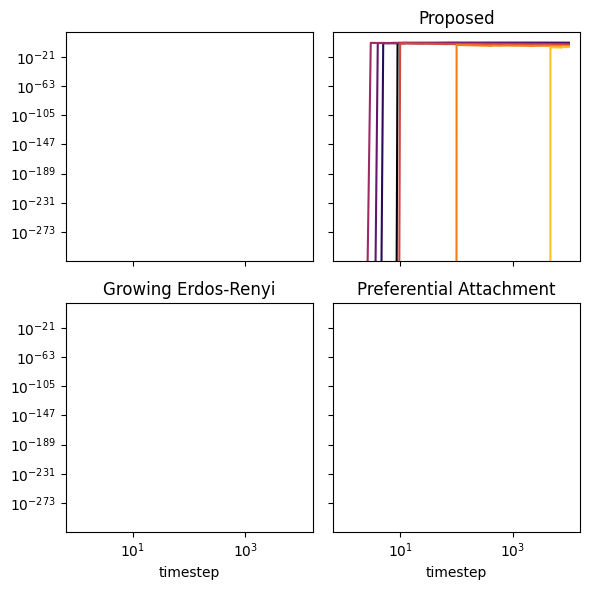

In [22]:
fig, axarr = plt.subplots(2, 2, figsize = (6, 6), sharey=True, sharex = True)

models = {
    "empirical" : "Empirical",
    "ours" : "Proposed",
    "PA" : "Preferential Attachment",
    "ER" : "Growing Erdos-Renyi"
}

for i, ax in enumerate(axarr.ravel()):
    print(i)
    if i == 0:
        step_type = "empirical"
        D, timesteps = H.intersection_profile(randomize = False, interval = interval)
        # for k in sorted(list(D.keys())): 
        #     if k <= max_k:
        #         ax.plot(timesteps, D[k], label = rf"$k = {k}$", color = inferno(k-1))
        
    
    elif i == 1: 
        H = m.GrowingHypergraph()
        H.add_edge((0, 1, 2, 3))
        H.add_edge((4, 5, 6, 7))
        H.add_edge((8, 9, 10, 11))
        step_type = "ours"
        for _ in range(num_steps):
            H.sample_edge(eta, gamma, beta, True)
        D, timesteps = H.intersection_profile(randomize = False, interval = interval)
        for k in sorted(list(D.keys())): 
            if k <= max_k:
                ax.plot(timesteps, D[k], label = rf"$k = {k}$", color = inferno(k-1))
        print(H.degree_sequence().mean(), H.edge_size_sequence().mean())
        ax.set(title = f"{models[step_type]}")
        
    elif i >= 2:
        step_type = ["ER", "PA"][i-2]
        H = m.GrowingHypergraph()
        H.add_edge((0, 1, 2, 3))
        H.add_edge((4, 5, 6, 7))
        H.add_edge((8, 9, 10, 11))
        
        for _ in range(num_steps):
            H.sample_edge_alternative(step_type, param_for_alternatives, beta)
        # D, timesteps = H.intersection_profile(randomize = False, interval = interval)
        # for k in sorted(list(D.keys())): 
        #     if k <= max_k:
        #         ax.plot(timesteps, D[k], label = rf"$k = {k}$", color = inferno(k-1))
        ax.set(title = f"{models[step_type]}")
        ax.set(xlabel = "timestep")
    ax.loglog()
plt.tight_layout()